# EPCOT Guest Flow — Exploratory Data Analysis (EDA)
#### By: Andrew Gentilcore

## Introduction
This notebook explores **simulated EPCOT guest movement data** to understand:
- How guest movement varies by **zone** and **time of day**
- Which rides tend to have the highest **actual wait times**
- How experience metrics like **fun score** and **frustration score** relate to waits and events

The goal is descriptive: identify patterns that could inform **crowd management** and **guest experience** decisions.


# Import Libraries & Load Data


#### We start by loading the dataset and reviewing a sample of records to understand what fields are available.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display options (optional)
pd.set_option('display.max_columns', None)


In [4]:
# If running from the same folder as the CSV, this will work as-is.
df = pd.read_csv("epcot_guest_flow_large_stable.csv", parse_dates=["event_timestamp"])


In [5]:
df.head()


,guest_id,event_timestamp,from_zone,to_zone,ride_name,ride_category,posted_wait_min,actual_wait_min,ride_duration_min,crowd_level,temperature_f,weather,festival,party_size,ticket_type,frustration_score,fun_score
0,736,2025-03-14 23:20:00,World Showcase Norway,World Nature,NaN,NaN,NaN,NaN,NaN,9.0,90.3,clear,Flower & Garden,4,park_hopper,6.18,2.13
1,92,2025-03-16 23:52:00,World Showcase Mexico,World Showcase China,NaN,NaN,NaN,NaN,NaN,6.0,85.1,clear,Flower & Garden,5,standard,3.02,4.15
2,3039,2025-03-16 12:32:00,World Showcase Canada,World Showcase Mexico,NaN,NaN,NaN,NaN,NaN,8.0,82.4,cloudy,Food & Wine,4,annual_pass,4.67,3.81
3,3400,2025-03-14 16:46:00,World Showcase Germany,World Showcase American Adventure,Remy's Ratatouille Adventure,family,61.977082,79.193853,6.0,8.0,74.2,clear,Flower & Garden,7,park_hopper,4.87,7.06
4,2341,2025-03-17 10:46:00,World Showcase American Adventure,World Nature,NaN,NaN,NaN,NaN,NaN,6.0,89.3,clear,none,4,standard,3.36,3.81


# Data Overview


#### Before analysis, we check basic dataset information (data types, missing values, and summary statistics).


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   guest_id           80000 non-null  int64         
 1   event_timestamp    80000 non-null  datetime64[ns]
 2   from_zone          80000 non-null  object        
 3   to_zone            80000 non-null  object        
 4   ride_name          31888 non-null  object        
 5   ride_category      31888 non-null  object        
 6   posted_wait_min    31888 non-null  float64       
 7   actual_wait_min    31888 non-null  float64       
 8   ride_duration_min  31888 non-null  float64       
 9   crowd_level        80000 non-null  float64       
 10  temperature_f      80000 non-null  float64       
 11  weather            80000 non-null  object        
 12  festival           80000 non-null  object        
 13  party_size         80000 non-null  int64         
 14  ticket

In [11]:
df.describe(include="all")


,guest_id,event_timestamp,from_zone,to_zone,ride_name,ride_category,posted_wait_min,actual_wait_min,ride_duration_min,crowd_level,temperature_f,weather,festival,party_size,ticket_type,frustration_score,fun_score
count,80000.000000,80000,80000,80000,31888,31888,31888.000000,31888.000000,31888.000000,80000.00000,80000.000000,80000,80000,80000.000000,80000,80000.000000,80000.000000
unique,NaN,NaN,15,14,14,3,NaN,NaN,NaN,NaN,NaN,4,4,NaN,3,NaN,NaN
top,NaN,NaN,World Showcase Germany,World Discovery,Mission: SPACE,family,NaN,NaN,NaN,NaN,NaN,clear,none,NaN,standard,NaN,NaN
freq,NaN,NaN,5420,5822,2366,18110,NaN,NaN,NaN,NaN,NaN,48063,39955,NaN,26695,NaN,NaN
mean,2495.071263,2025-03-16 02:57:18.734250240,NaN,NaN,NaN,NaN,39.230921,35.344610,10.100728,6.98720,81.977178,NaN,NaN,3.996425,NaN,4.598461,4.791723
min,1.000000,2025-03-14 09:00:00,NaN,NaN,NaN,NaN,5.000000,1.639085,4.000000,1.00000,61.100000,NaN,NaN,1.000000,NaN,1.000000,1.000000
25%,1240.750000,2025-03-15 05:57:45,NaN,NaN,NaN,NaN,16.664634,14.440763,5.000000,6.00000,78.600000,NaN,NaN,2.000000,NaN,3.490000,3.850000
50%,2496.000000,2025-03-16 02:57:00,NaN,NaN,NaN,NaN,29.384664,25.969503,8.000000,7.00000,82.000000,NaN,NaN,4.000000,NaN,4.530000,4.760000
75%,3741.000000,2025-03-16 23:56:00,NaN,NaN,NaN,NaN,58.544937,50.693414,15.000000,8.00000,85.400000,NaN,NaN,6.000000,NaN,5.640000,5.700000
max,4999.000000,2025-03-17 20:59:00,NaN,NaN,NaN,NaN,153.739627,183.615197,30.000000,10.00000,102.800000,NaN,NaN,7.000000,NaN,10.000000,10.000000


# Feature Engineering


#### Create a few helpful fields for time-based analysis and to flag ride events.


In [13]:
df['hour'] = df['event_timestamp'].dt.hour
df['date'] = df['event_timestamp'].dt.date
df['ride_event'] = df['ride_name'].notna()


# Zone Congestion by Time of Day



### Interpretation

Several EPCOT zones show clear time-of-day patterns rather than uniform activity.
Some zones experience sharp spikes during specific hours, while others maintain
steady inflow across much of the day.

Zones with sustained inflow over multiple hours may indicate areas where guests
tend to linger or transition through frequently, which can contribute to localized
crowding. In contrast, zones with brief but intense peaks may be tied to scheduled
events, dining patterns, or nearby attractions.

From an operations perspective, understanding *when* congestion forms is just as
important as *where*. Time-specific patterns can inform staffing, guest routing,
or targeted messaging during peak periods.


#### To understand where guests tend to accumulate, we count movement events flowing into each zone by hour.


In [15]:
zone_congestion = (
    df.groupby(['to_zone', 'hour'])
      .size()
      .reset_index(name='event_count')
)
zone_congestion.head()


,to_zone,hour,event_count
0,World Celebration,0,204
1,World Celebration,1,207
2,World Celebration,2,187
3,World Celebration,3,206
4,World Celebration,4,211


## Congestion Heatmap


#### Pivot the zone/hour counts into a matrix to visualize patterns throughout the day.


In [17]:
pivot_zone = zone_congestion.pivot(index='to_zone', columns='hour', values='event_count')
pivot_zone


hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
to_zone,,,,,,,,,,,,,,,,,,,,,,,,
World Celebration,204,207,187,206,211,179,209,222,183,272,291,251,286,292,287,296,274,269,264,282,265,225,209,221
World Discovery,191,206,194,228,203,217,200,217,204,260,263,273,280,313,273,261,270,279,313,273,267,187,218,232
World Nature,209,173,186,208,210,180,217,200,226,268,277,295,287,274,304,287,254,273,270,285,238,228,213,194
World Showcase American Adventure,189,190,203,185,202,191,188,193,211,248,275,279,258,279,251,276,286,279,316,261,293,209,206,205
World Showcase Canada,207,189,195,228,195,208,184,216,212,290,284,264,285,276,273,282,280,271,275,270,268,179,199,175
World Showcase China,232,191,199,184,204,208,201,210,200,275,262,267,277,281,270,257,270,275,273,301,283,210,202,220
World Showcase France,192,226,201,223,214,196,209,186,205,304,260,264,275,241,271,244,271,297,279,266,282,232,221,194
World Showcase Germany,231,190,187,197,198,196,219,186,225,268,264,300,256,239,298,277,235,253,254,291,253,221,220,196
World Showcase Italy,220,228,193,189,197,190,196,226,202,270,257,284,281,277,286,287,257,292,262,272,231,186,180,182


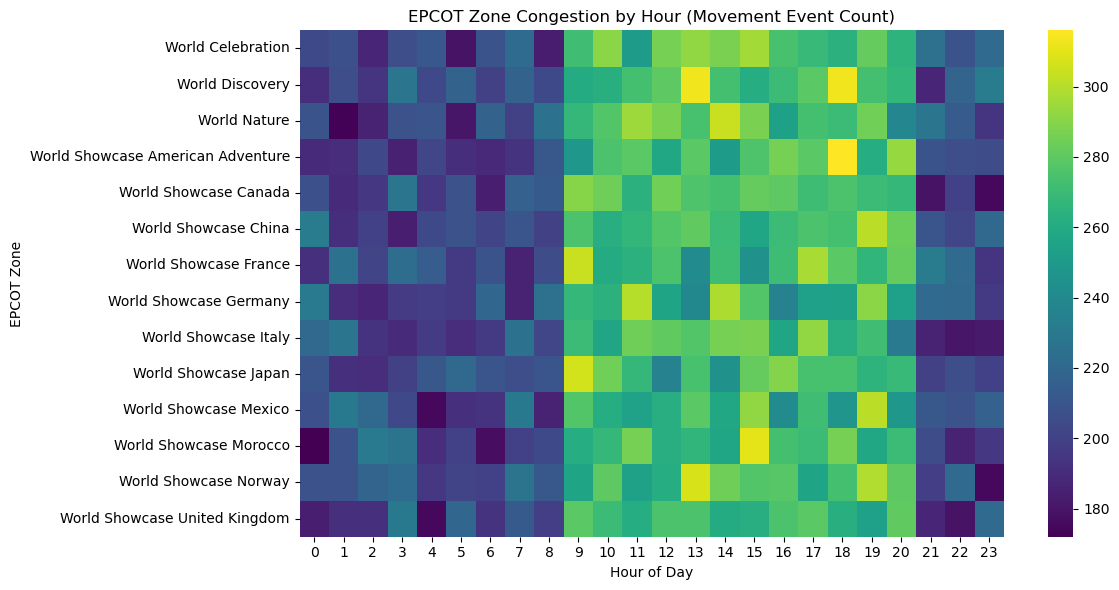

In [19]:
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_zone.fillna(0), cmap='viridis')
plt.title('EPCOT Zone Congestion by Hour (Movement Event Count)')
plt.xlabel('Hour of Day')
plt.ylabel('EPCOT Zone')
plt.tight_layout()
plt.show()


### Interpretation
Zones with consistently darker bands across multiple hours may indicate sustained inflow or high activity.
Looking at **when** congestion spikes can help frame staffing, routing, or experience improvements.


# Ride Wait Time Analysis



### Interpretation

The rides with the highest average actual wait times represent attractions that
consistently demand a significant time investment from guests, not just occasional
spikes.

While longer waits do not automatically imply a negative experience, they can
increase the likelihood of guest frustration—especially during peak hours or when
expectations are not aligned with actual wait time.

In a real park setting, this type of analysis could support decisions around
capacity adjustments, queue design, or guest communication strategies.


#### Next, I focused on ride events and summarized which rides tend to have the highest average **actual** wait time.


In [21]:
avg_waits = (
    df[df['ride_event']]
      .groupby('ride_name')['actual_wait_min']
      .mean()
      .sort_values(ascending=False)
)
avg_waits.head(15)


ride_name
Guardians of the Galaxy: Cosmic Rewind    75.496421
Remy's Ratatouille Adventure              68.973251
Frozen Ever After                         64.687847
Test Track                                59.317219
Soarin' Around the World                  48.940012
Mission: SPACE                            34.784559
Spaceship Earth                           29.900884
Living with the Land                      24.900002
Journey Into Imagination with Figment     19.737647
The Seas with Nemo & Friends              19.715216
Gran Fiesta Tour                          14.921103
Beauty and the Beast Sing-Along           14.786940
Reflections of China                       9.987916
The American Adventure                     9.893667
Name: actual_wait_min, dtype: float64

In [ ]:
plt.figure(figsize=(10, 6))
avg_waits.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Rides by Average Actual Wait Time')
plt.xlabel('Average Actual Wait (Minutes)')
plt.ylabel('Ride Name')
plt.tight_layout()
plt.show()


### Interpretation
#### This chart helps identify which attractions tend to create the largest time-cost for guests. In a real operational setting, this could inform capacity, messaging, or queue management.


# Experience Metrics: Fun vs. Frustration



### Interpretation

#### The relationship between wait time and frustration appears positive but notperfectly linear. While longer waits generally correspond to higher frustration, there is noticeable variability across guests. This suggests that factors beyond wait time, such as ride popularity, theming, or perceived value, may influence how guests experience waiting.


#### The dataset includes experience metrics. We examine how **frustration** relates to wait time, and how it relates to **fun score**.


In [28]:
sample_df = df.dropna(subset=['fun_score', 'frustration_score']).sample(5000, random_state=42)


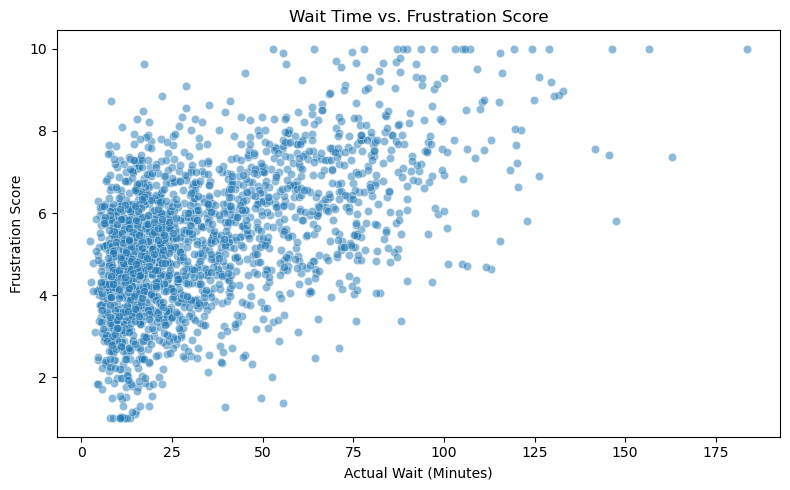

In [30]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample_df, x='actual_wait_min', y='frustration_score', alpha=0.5)
plt.title('Wait Time vs. Frustration Score')
plt.xlabel('Actual Wait (Minutes)')
plt.ylabel('Frustration Score')
plt.tight_layout()
plt.show()


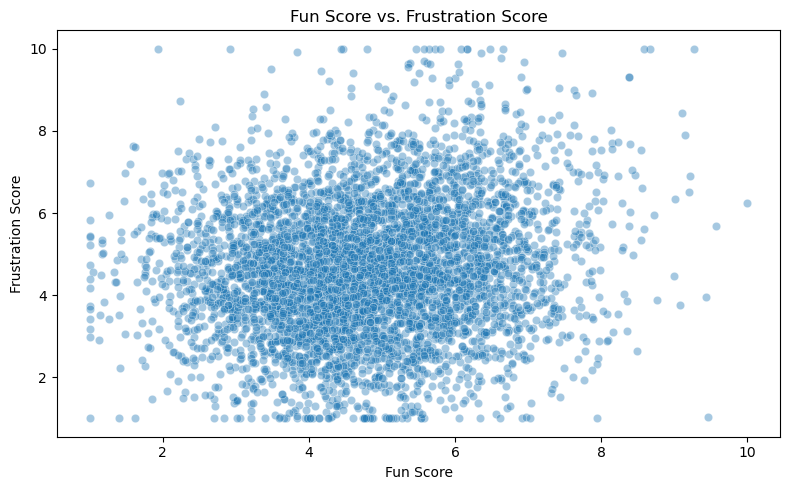

In [32]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample_df, x='fun_score', y='frustration_score', alpha=0.4)
plt.title('Fun Score vs. Frustration Score')
plt.xlabel('Fun Score')
plt.ylabel('Frustration Score')
plt.tight_layout()
plt.show()


#### These plots help validate whether increased waits are associated with higher frustration, and whether fun and frustration show an expected tradeoff. The goal is to **describe relationships**, not claim causality.


# Festival Comparison


#### Differences in fun score distributions across festivals suggest that the overall guest experience can vary meaningfully depending on seasonal offerings, crowd composition, or event-specific activities.

#### Some festivals show higher median fun scores with tighter distributions, indicating a more consistent experience, while others display wider variability that may reflect mixed guest responses.


#### If the dataset contains festival labels, we can compare average fun/frustration by festival and visualize distributions.


In [ ]:
festival_summary = df.groupby('festival')[['fun_score','frustration_score']].mean().sort_values('fun_score', ascending=False)
festival_summary


In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='festival', y='fun_score')
plt.xticks(rotation=45, ha='right')
plt.title('Fun Score by Festival')
plt.xlabel('Festival')
plt.ylabel('Fun Score')
plt.tight_layout()
plt.show()


# Conclusion
### This analysis explored EPCOT guest movement and experience metrics with a descriptive lens.
#### Zone/hour congestion patterns help highlight **when and where** activity concentrates.
#### Ride wait summaries help identify attractions that contribute to higher time cost.
#### Experience metric relationships (fun/frustration) help frame guest impact alongside operations.

#### Next steps could include linking movement flows to wait outcomes by zone, or building a small dashboard to track these metrics over time.
